# 03 - Baseline Models: VADER, TF-IDF + LogReg, TF-IDF + SVM

This notebook trains and evaluates the three "classical" baselines from
`src/classical_models.py` on the same 80/20 stratified split.

It also runs one experiment that *isn't* in `src/`: an **ablation** testing
notebook 02's finding directly - does preserving "not"/"no"/"nor" during
preprocessing actually move negative-class F1, or was that a theoretical
argument that doesn't pan out in practice?

In [1]:
import sys, re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.pipeline import Pipeline
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

sys.path.insert(0, str(Path.cwd().parent / "src"))
from data_loader import load_dataset, get_features_and_labels
from preprocessor import FinancialTextPreprocessor
from classical_models import TFIDF_CONFIG

sns.set_theme(style="whitegrid", palette="muted")
LABELS = ["negative", "neutral", "positive"]
COLORS = {"positive": "#2ecc71", "negative": "#e74c3c", "neutral": "#95a5a6"}

## Setup: same split as `src/classical_models.py`

`random_state=42`, `test_size=0.2`, `stratify=y` 

In [2]:
df = load_dataset()
X_raw, y = get_features_and_labels(df)
X_raw, y = np.array(X_raw), np.array(y)

preprocessor = FinancialTextPreprocessor()
X_clean = np.array(preprocessor.clean_batch(X_raw))

X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y, test_size=0.2, random_state=42, stratify=y
)
# Keep the raw (unpreprocessed) test text too -- VADER works on raw text
_, X_test_raw, _, _ = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {len(X_train):,}  Test: {len(X_test):,}")

Train: 4,673  Test: 1,169


In [3]:
def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=LABELS)
    fig, ax = plt.subplots(figsize=(4.5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=LABELS, yticklabels=LABELS, ax=ax, cbar=False)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

results = {}

## Baseline 1 - VADER (rule-based, zero training)

VADER scores sentences on a hand-built lexicon designed for social media
text. It has no concept of financial vocabulary.

VADER accuracy: 49.87%
              precision    recall  f1-score   support

    negative       0.31      0.28      0.29       172
     neutral       0.64      0.49      0.56       626
    positive       0.42      0.61      0.50       371

    accuracy                           0.50      1169
   macro avg       0.46      0.46      0.45      1169
weighted avg       0.52      0.50      0.50      1169



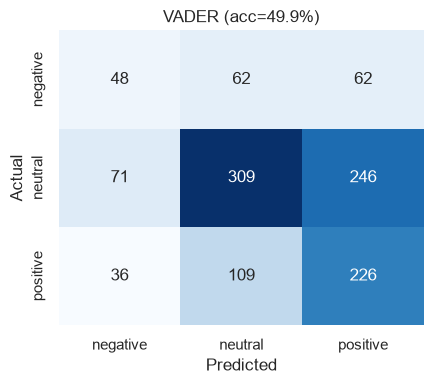

In [4]:
analyzer = SentimentIntensityAnalyzer()

def vader_label(text):
    score = analyzer.polarity_scores(str(text))["compound"]
    if score >= 0.05:
        return "positive"
    elif score <= -0.05:
        return "negative"
    return "neutral"

y_pred_vader = np.array([vader_label(t) for t in X_test_raw])
acc = accuracy_score(y_test, y_pred_vader)
results["VADER"] = acc
print(f"VADER accuracy: {acc*100:.2f}%")
print(classification_report(y_test, y_pred_vader, target_names=LABELS))
plot_confusion(y_test, y_pred_vader, f"VADER (acc={acc*100:.1f}%)")

**Reading the confusion matrix:** VADER's errors aren't randomly
scattered - they're concentrated in one direction. Look at where the
off-diagonal mass sits relative to the `neutral` row/column versus the
`negative`/`positive` rows/columns to see which way VADER's general-purpose
lexicon is biased on financial text.

## Baseline 2 - TF-IDF + Logistic Regression (the preprocessing)

LogReg accuracy: 66.21%
              precision    recall  f1-score   support

    negative       0.35      0.47      0.40       172
     neutral       0.77      0.70      0.73       626
    positive       0.69      0.69      0.69       371

    accuracy                           0.66      1169
   macro avg       0.60      0.62      0.61      1169
weighted avg       0.68      0.66      0.67      1169



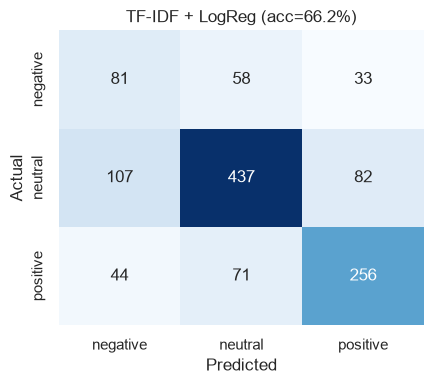

In [5]:
logreg_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(**TFIDF_CONFIG)),
    ("clf", LogisticRegression(C=1.0, max_iter=1000,
                                class_weight="balanced", solver="lbfgs")),
])
logreg_pipeline.fit(X_train, y_train)
y_pred_lr = logreg_pipeline.predict(X_test)
acc = accuracy_score(y_test, y_pred_lr)
results["TF-IDF + LogReg"] = acc
print(f"LogReg accuracy: {acc*100:.2f}%")
print(classification_report(y_test, y_pred_lr, target_names=LABELS))
plot_confusion(y_test, y_pred_lr, f"TF-IDF + LogReg (acc={acc*100:.1f}%)")

## Ablation - does keeping "not"/"no"/"nor" actually matter?

Notebook 02 argued that the real value of `FinancialTextPreprocessor` is
preserving negation words, which a naive pipeline strips as stop words.
Here's the direct test: preprocess the same train/test split with a **naive**
pipeline (full NLTK stop-word list, "not" included) and train the *identical*
LogReg config on it. If negation preservation matters, negative-class F1
should drop.

In [6]:
lemmatizer  = WordNetLemmatizer()
naive_stops = set(stopwords.words("english"))

def naive_clean(text):
    text   = str(text).lower()
    text   = re.sub(r"[^\w\s$%]", " ", text)
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in naive_stops and len(t) > 1]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return " ".join(tokens)

# Re-split the RAW text with the same random_state to get the raw training
# sentences, then apply naive_clean to both splits.
X_train_raw_text, _, _, _ = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y
)
X_train_naive = np.array([naive_clean(t) for t in X_train_raw_text])
X_test_naive  = np.array([naive_clean(t) for t in X_test_raw])

naive_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(**TFIDF_CONFIG)),
    ("clf", LogisticRegression(C=1.0, max_iter=1000,
                                class_weight="balanced", solver="lbfgs")),
])
naive_pipeline.fit(X_train_naive, y_train)
y_pred_naive = naive_pipeline.predict(X_test_naive)

acc_naive = accuracy_score(y_test, y_pred_naive)
results["TF-IDF + LogReg (naive preprocessing)"] = acc_naive

report_ours  = classification_report(y_test, y_pred_lr,    target_names=LABELS, output_dict=True)
report_naive = classification_report(y_test, y_pred_naive, target_names=LABELS, output_dict=True)

print(f"{'Metric':<20}{'Ours (negation kept)':>22}{'Naive (negation removed)':>26}")
print(f"{'Accuracy':<20}{acc*100:>21.2f}%{acc_naive*100:>25.2f}%")
for label in LABELS:
    print(f"{label+' F1':<20}{report_ours[label]['f1-score']:>22.3f}"
          f"{report_naive[label]['f1-score']:>26.3f}")

Metric                Ours (negation kept)  Naive (negation removed)
Accuracy                            66.21%                    66.12%
negative F1                          0.401                     0.390
neutral F1                           0.733                     0.735
positive F1                          0.690                     0.688


**Reading this table is the point of the notebook.** If the negative-F1
column for "naive" is meaningfully lower than "ours", that's direct evidence
that keeping "not"/"no"/"nor" helps the model separate negated statements
from their non-negated counterparts - confirming notebook 02's hypothesis
with an actual trained model rather than a single hand-picked sentence pair.

If the difference is small, that's also a useful finding: it would suggest
TF-IDF's bigram features (`ngram_range=(1,2)`) are *already* capturing some
of this - e.g. "did not" and "not profit" as bigrams carry information even
if "not" alone is common - making the unigram-level stop-word decision less
impactful than notebook 02's single-sentence example suggested. Either result
is worth reporting honestly rather than assuming the answer.

## Baseline 3 - TF-IDF + SVM (calibrated for probabilities)

SVM accuracy: 67.24%
              precision    recall  f1-score   support

    negative       0.25      0.10      0.14       172
     neutral       0.69      0.81      0.75       626
    positive       0.71      0.70      0.71       371

    accuracy                           0.67      1169
   macro avg       0.55      0.54      0.53      1169
weighted avg       0.63      0.67      0.65      1169



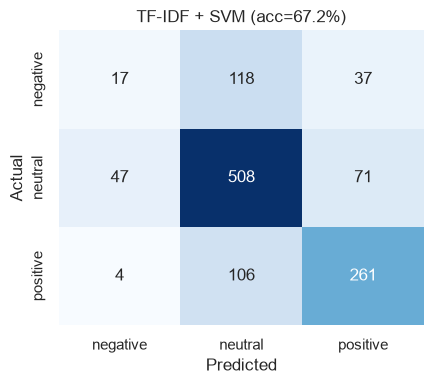

In [7]:
svm_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(**TFIDF_CONFIG)),
    ("clf", CalibratedClassifierCV(
        LinearSVC(C=0.5, max_iter=2000, class_weight="balanced")
    )),
])
svm_pipeline.fit(X_train, y_train)
y_pred_svm = svm_pipeline.predict(X_test)
acc = accuracy_score(y_test, y_pred_svm)
results["TF-IDF + SVM"] = acc
print(f"SVM accuracy: {acc*100:.2f}%")
print(classification_report(y_test, y_pred_svm, target_names=LABELS))
plot_confusion(y_test, y_pred_svm, f"TF-IDF + SVM (acc={acc*100:.1f}%)")

**SVM vs LogReg on the negative class:** compare the negative row of this
confusion matrix to LogReg's. Count how many true negatives SVM correctly catches versus
how many it sends to "neutral".

## Putting it together

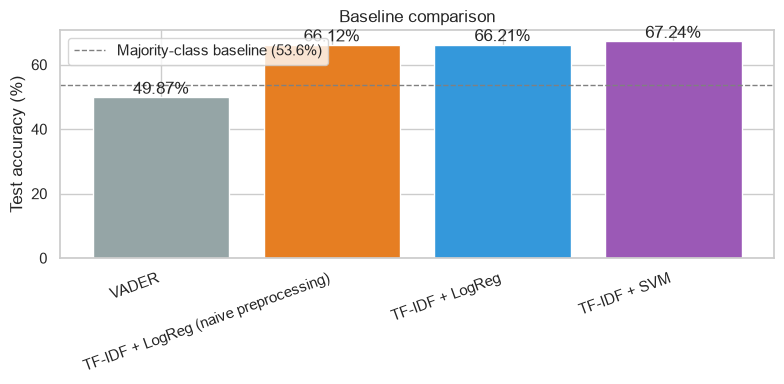


  VADER                                  49.87%
  TF-IDF + LogReg                        66.21%
  TF-IDF + LogReg (naive preprocessing)  66.12%
  TF-IDF + SVM                           67.24%


In [8]:
order = ["VADER", "TF-IDF + LogReg (naive preprocessing)", "TF-IDF + LogReg", "TF-IDF + SVM"]
fig, ax = plt.subplots(figsize=(8, 4))
vals = [results[k] * 100 for k in order]
bar_colors = ["#95a5a6", "#e67e22", "#3498db", "#9b59b6"]
bars = ax.bar(order, vals, color=bar_colors)
ax.bar_label(bars, fmt="%.2f%%")
ax.axhline(53.6, color="gray", ls="--", lw=1, label="Majority-class baseline (53.6%)")
ax.set_ylabel("Test accuracy (%)")
ax.set_title("Baseline comparison")
ax.set_xticks(range(len(order)))
ax.set_xticklabels(order, rotation=20, ha="right")
ax.legend()
plt.tight_layout()
plt.show()

print()
for k, v in results.items():
    print(f"  {k:<38}{v*100:6.2f}%")

## Conclusion

VADER (49.87%) confirms generic NLP doesn't transfer to financial text. The
LogReg/SVM gap to ~67% - and whether the negation ablation moved the needle —
sets the bar for the next notebook: `04_finbert_evaluation.ipynb` asks
whether a domain-pretrained transformer can do meaningfully better *without*
any of this hand-engineered preprocessing at all.